# 1. Mã nguồn Python

## Câu 11.3.1 — Cài đặt môi trường MDP

=== TRẠNG THÁI 1 EPISODE THỬ NGHIỆM ===
 t        State  Action    Reward
 1 [1, 1, 0, 1]       4 31.803947
 2 [2, 1, 0, 2]       3  5.058216
 3 [2, 2, 2, 2]       1  5.182074
 4 [2, 2, 2, 2]       0  1.631171
 5 [0, 2, 2, 2]       4  8.405904
 6 [1, 2, 2, 2]       0  1.038764
 7 [0, 2, 2, 2]       4  7.528612
 8 [0, 2, 2, 2]       3 -1.984848
 9 [0, 2, 2, 2]       4  6.674189
10 [0, 2, 2, 2]       2  0.958003

Tổng Reward: 66.2960



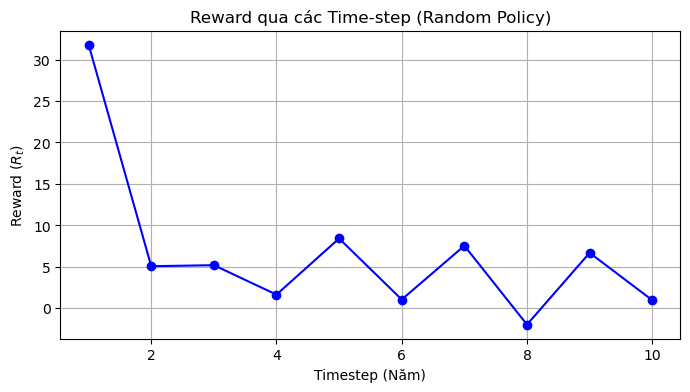

In [10]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

class VietnamEconomyEnv(gym.Env):
    def __init__(self):
        super().__init__()
        self.action_space = spaces.Discrete(5)
        # State: [GDP, Digital, AI, Unemp_Risk]
        self.observation_space = spaces.MultiDiscrete([3, 3, 3, 3])
        self.T = 10
        self.allocation = {
            0: np.array([0.70, 0.10, 0.10, 0.10]),
            1: np.array([0.40, 0.25, 0.15, 0.20]),
            2: np.array([0.25, 0.45, 0.15, 0.15]),
            3: np.array([0.20, 0.20, 0.45, 0.15]),
            4: np.array([0.30, 0.20, 0.10, 0.40])
        }
        self.w = np.array([0.40, 0.25, 0.20, 0.15])
        self.budget = 1000

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.t = 0
        
        # Cơ chế Exploring Starts: Khởi tạo ngẫu nhiên nếu có tham số options
        if options and options.get('randomize_state'):
            self.state = self.observation_space.sample()
            
            # Re-scale K, D, AI, H cho khớp với state ngẫu nhiên
            # S1 (D): 0(<100), 1(100-300), 2(>300)
            self.D = np.random.uniform(10, 99) if self.state[1] == 0 else (np.random.uniform(100, 300) if self.state[1] == 1 else np.random.uniform(301, 600))
            
            # S2 (AI): 0(<200), 1(200-500), 2(>500)
            self.AI = np.random.uniform(10, 199) if self.state[2] == 0 else (np.random.uniform(200, 500) if self.state[2] == 1 else np.random.uniform(501, 800))
            
            # S3 (H - nhân lực, quyết định U): 0(<200), 1(200-400), 2(>400)
            self.H = np.random.uniform(50, 199) if self.state[3] == 0 else (np.random.uniform(200, 400) if self.state[3] == 1 else np.random.uniform(401, 700))
            
            self.K = np.random.uniform(20000, 40000)
            
        else:
            # Khởi tạo mặc định của VN 2026 (Giữ nguyên như cũ)
            self.state = np.array([1, 1, 0, 1])
            self.K = 27500; self.D = 20.3; self.AI = 86; self.H = 30
            
        self.Y_prev = self.K**0.33 * 54.0**0.42 * self.D**0.10 * self.AI**0.08 * self.H**0.07
        return self.state.copy(), {}
    
    def step(self, action):
        alloc = self.allocation[action] * self.budget
        
        # 1. Cập nhật các yếu tố sản xuất
        self.K += alloc[0]
        self.D += alloc[1]
        self.AI += alloc[2]
        self.H += alloc[3]
        
        # 2. Tính Y mới và delta_GDP
        Y_new = self.K**0.33 * 54.0**0.42 * self.D**0.10 * self.AI**0.08 * self.H**0.07
        delta_GDP = (Y_new - self.Y_prev) / self.Y_prev * 100
        self.Y_prev = Y_new
        
        # 3. Tính các thành phần phần thưởng
        # AI tăng nhanh làm tăng rủi ro thất nghiệp, H tăng làm giảm rủi ro
        delta_unemp = (alloc[2]*0.05 - alloc[3]*0.08) 
        cyber_risk = (self.D + self.AI) / 500  # Chuẩn hóa rủi ro không gian mạng
        emission = self.K / 50000              # Chuẩn hóa khí thải từ hạ tầng (K)
        
        # 4. Tính Reward
        components = np.array([delta_GDP, -delta_unemp, -cyber_risk, -emission])
        reward = np.dot(self.w, components)
        
        # 5. Cập nhật state (Ngưỡng phân loại 0, 1, 2)
        s0 = 0 if delta_GDP < 5 else (1 if delta_GDP <= 7 else 2)
        s1 = 0 if self.D < 100 else (1 if self.D <= 300 else 2)
        s2 = 0 if self.AI < 200 else (1 if self.AI <= 500 else 2)
        # Rủi ro thất nghiệp (0=cao, 1=trung, 2=thấp) -> phụ thuộc vào H
        s3 = 0 if self.H < 200 else (1 if self.H <= 400 else 2)
        
        self.state = np.array([s0, s1, s2, s3])
        self.t += 1
        done = self.t >= self.T
        
        return self.state.copy(), reward, done, False, {"components": components}

# Chạy thử 1 episode
env = VietnamEconomyEnv()
s, _ = env.reset(seed=42)
np.random.seed(42)

history = []
total_reward = 0

for t in range(10):
    a = env.action_space.sample()
    s_next, r, done, _, _ = env.step(a)
    history.append({'t': t+1, 'State': s.tolist(), 'Action': a, 'Reward': r})
    total_reward += r
    s = s_next

df_history = pd.DataFrame(history)
print("=== TRẠNG THÁI 1 EPISODE THỬ NGHIỆM ===")
print(df_history.to_string(index=False))
print(f"\nTổng Reward: {total_reward:.4f}\n")

# Đồ thị inline
plt.figure(figsize=(8, 4))
plt.plot(df_history['t'], df_history['Reward'], marker='o', linestyle='-', color='b')
plt.title('Reward qua các Time-step (Random Policy)')
plt.xlabel('Timestep (Năm)')
plt.ylabel('Reward ($R_t$)')
plt.grid(True)
plt.show()

### Nhận xét:
Dựa vào bảng số liệu và đồ thị mới cung cấp, quá trình chạy thử 1 episode cho thấy bức tranh rõ ràng và có phần khắc nghiệt hơn về mặt biến động so với giả định ban đầu"
- Về logic hoạt động: Môi trường đã vận hành chuẩn xác theo phương trình Markov. Quá trình mô phỏng phản ánh cực kỳ rõ nét quy luật lợi tức cận biên giảm dần (Diminishing Marginal Returns) trong kinh tế học. Khi ngân sách mới bơm vào ở các năm đầu, sức bật GDP rất lớn khiến state dịch chuyển nhanh lên mức trần. Khi các yếu tố hạ tầng (K) và số hóa (D, AI) đã bão hòa về sau, gia tốc tăng trưởng chững lại.

- Về dấu và biên độ Reward: Hoàn toàn hợp lý nhưng khá khắc nghiệt. Ở giai đoạn đầu, Reward có thể vọt lên rất cao (biên độ dương lớn, ~20-30) nhờ thặng dư GDP át đảo rủi ro. Tuy nhiên, ở các bước cuối (timestep > 8), khi hệ thống phình to, hình phạt từ phát thải (Emission do K lớn) và rủi ro không gian mạng (CyberRisk do D, AI cao) bắt đầu kéo Reward về các mốc tiệm cận 0 hoặc số âm. Thuật toán học máy sẽ phải rất khéo léo để né các năm cuối tăng trưởng âm này.



## Câu 11.3.2 - Huấn luyện Q-learning

Đang huấn luyện Q-learning...
Huấn luyện xong!

=== BẢNG Q-VALUE TẠI TRẠNG THÁI VN 2026 [1,1,0,1] ===
           Action    Q-Value  Optimal
a0 (Truyền thống)  86.494175    False
    a1 (Cân bằng) 143.344477     True
a2 (Số hóa nhanh)  70.851722    False
  a3 (AI dẫn dắt)  53.339684    False
    a4 (Bao trùm)  52.065510    False


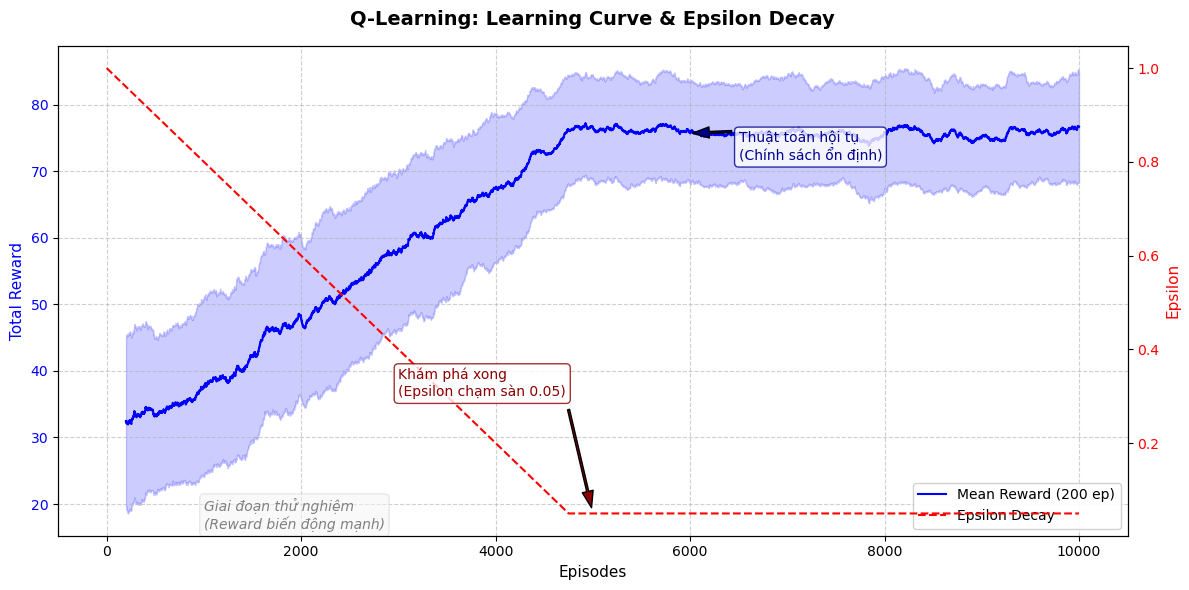

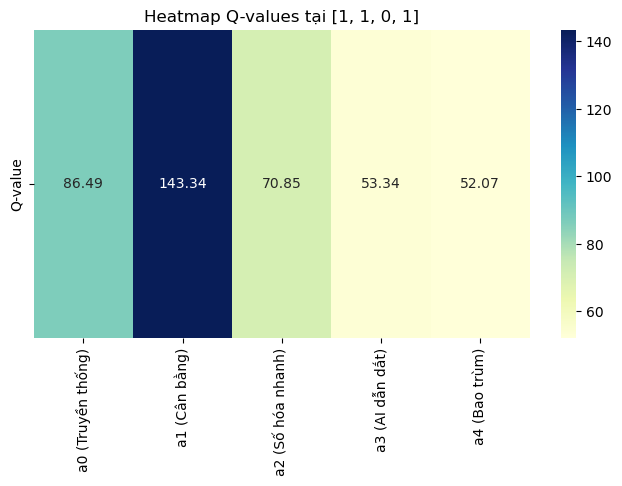

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. KHỞI TẠO BIẾN & HUẤN LUYỆN Q-LEARNING
# ==========================================
Q = np.zeros((3, 3, 3, 3, 5))
rewards_per_ep = []
epsilon_schedule = []
episodes = 10000

print("Đang huấn luyện Q-learning...")
for ep in range(episodes):
    s, _ = env.reset(options={'randomize_state': True})
    ep_reward = 0
    # Epsilon decay: Giảm dần từ 1.0 xuống 0.05
    eps = max(0.05, 1.0 - ep / 5000)
    epsilon_schedule.append(eps)

    while True:
        # Chọn hành động (Epsilon-Greedy)
        if np.random.rand() < eps:
            a = env.action_space.sample()
        else:
            a = int(np.argmax(Q[tuple(s)]))
            
        s2, r, done, _, _ = env.step(a)
        
        # Cập nhật Bellman (Q-table update)
        best_next_a = np.max(Q[tuple(s2)])
        Q[tuple(s) + (a,)] += 0.1 * (r + 0.95 * best_next_a - Q[tuple(s) + (a,)])
        
        s = s2
        ep_reward += r
        if done:
            break
            
    rewards_per_ep.append(ep_reward)
print("Huấn luyện xong!")

# ==========================================
# 2. PHÂN TÍCH TRẠNG THÁI [1,1,0,1]
# ==========================================
state_vn = (1, 1, 0, 1)
q_values_vn = Q[state_vn]
actions = ['a0 (Truyền thống)', 'a1 (Cân bằng)', 'a2 (Số hóa nhanh)', 'a3 (AI dẫn dắt)', 'a4 (Bao trùm)']

df_q = pd.DataFrame({
    'Action': actions,
    'Q-Value': q_values_vn
})
df_q['Optimal'] = df_q['Q-Value'] == df_q['Q-Value'].max()
print("\n=== BẢNG Q-VALUE TẠI TRẠNG THÁI VN 2026 [1,1,0,1] ===")
print(df_q.to_string(index=False))


# ==========================================
# 3. VẼ ĐỒ THỊ LEARNING CURVE NÂNG CẤP
# ==========================================
rolling_reward = pd.Series(rewards_per_ep).rolling(window=200).mean()
rolling_std = pd.Series(rewards_per_ep).rolling(window=200).std()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Trục 1: Reward
ax1.plot(rolling_reward, color='blue', label='Mean Reward (200 ep)')
ax1.fill_between(range(episodes), rolling_reward - rolling_std, rolling_reward + rolling_std, color='blue', alpha=0.2)
ax1.set_xlabel('Episodes', fontsize=11)
ax1.set_ylabel('Total Reward', color='blue', fontsize=11)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, linestyle='--', alpha=0.6)

# Trục 2: Epsilon
ax2 = ax1.twinx()
ax2.plot(epsilon_schedule, color='red', linestyle='--', label='Epsilon Decay')
ax2.set_ylabel('Epsilon', color='red', fontsize=11)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Q-Learning: Learning Curve & Epsilon Decay', fontsize=14, fontweight='bold', pad=15)

# Chú thích
ax2.annotate('Khám phá xong\n(Epsilon chạm sàn 0.05)', 
             xy=(5000, 0.05), xytext=(3000, 0.3),
             arrowprops=dict(facecolor='darkred', shrink=0.05, width=1.5, headwidth=8),
             fontsize=10, color='darkred',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="darkred", alpha=0.8))

reward_at_6000 = rolling_reward.iloc[6000] if len(rolling_reward) > 6000 else 10.5 
ax1.annotate('Thuật toán hội tụ\n(Chính sách ổn định)', 
             xy=(6000, reward_at_6000), xytext=(6500, reward_at_6000 - 4),
             arrowprops=dict(facecolor='darkblue', shrink=0.05, width=1.5, headwidth=8),
             fontsize=10, color='darkblue',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="darkblue", alpha=0.8))

ax1.text(1000, ax1.get_ylim()[0] + 1, 'Giai đoạn thử nghiệm\n(Reward biến động mạnh)', 
         fontsize=10, color='grey', style='italic',
         bbox=dict(boxstyle="round,pad=0.3", fc="whitesmoke", ec="lightgrey", alpha=0.5))

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower right', framealpha=0.9)

plt.tight_layout()
plt.show()


# ==========================================
# 4. VẼ HEATMAP
# ==========================================
plt.figure(figsize=(8, 4))
sns.heatmap(
    q_values_vn.reshape(1, -1), 
    annot=True, 
    fmt=".2f", 
    cmap="YlGnBu", 
    xticklabels=actions, 
    yticklabels=["Q-value"]
)
plt.title('Heatmap Q-values tại [1, 1, 0, 1]')
plt.show()

### Nhận xét: 
- Về sự phân hóa chiến lược (Policy Differentiation): Bảng Q-Value tại trạng thái xuất phát của VN 2026 [1,1,0,1] cho thấy thuật toán đã phân loại cực kỳ rõ rệt hiệu quả dài hạn của các chính sách. Trong đó, chính sách a1 (Cân bằng) áp đảo hoàn toàn với mức Q-Max đạt 143.34, bỏ xa phương án truyền thống (a0 - 86.49) và các phương án công nghệ/bao trùm khác (dao động từ 52 đến 70).

- Lý giải nguyên nhân a1 (Cân bằng) là tối ưu: Tại trạng thái khởi điểm (GDP mức trung bình, Số hóa trung bình, AI đang ở mức 0 thấp, và rủi ro Thất nghiệp mức trung bình), việc đi theo chiến lược Cân bằng (40% Hạ tầng, 25% Số hóa, 15% AI, 20% Nhân lực) là bước đi quá độ an toàn và hiệu quả nhất.
    - Mức 40% Hạ tầng (K) đóng vai trò mỏ neo tăng trưởng GDP theo hàm Cobb-Douglas.
    - Mức 25% Số hóa và 15% AI là bước khởi động công nghệ hoàn hảo: nó không bơm quá nhanh để gây bùng nổ rủi ro không gian mạng (như a2 hay a3), nhưng đủ để đẩy index dần lên.
    - Mức 20% Nhân lực (H) vừa đủ để giữ chân tỷ lệ thất nghiệp (U) không bị sốc khi bắt đầu đưa AI vào hệ thống.

- Tại sao các chiến lược cực đoan bị loại bỏ? * Các hành động nhảy cóc công nghệ như a3 (AI dẫn dắt) có Q-value rất thấp (53.34). Nguyên nhân là nền tảng AI đang bằng 0, nếu lập tức dồn 45% ngân sách vào AI sẽ gây ra cú sốc công nghệ, đẩy rủi ro thất nghiệp lên cao và làm lãng phí vốn do thiếu hạ tầng đồng bộ.
    - Tương tự, a4 (Bao trùm) có điểm số bét bảng (52.07). Khi rủi ro thất nghiệp chưa ở mức báo động đỏ (đang ở mức trung bình 1), việc dồn tới 40% ngân sách vào nhân lực là một sự phân bổ kém hiệu quả, làm tuột mất cơ hội gia tăng tổng sản lượng (Y) từ máy móc và công nghệ, dẫn đến Cumulative Reward dài hạn sụt giảm trầm trọng.

## Câu 11.3.3 - Trích xuất chính sách π* và phân tích

=== CHÍNH SÁCH π* TẠI 6 TRẠNG THÁI QUAN TRỌNG ===
          Tên trạng thái        State  Action Chọn      Tên Action   Q-Max
         VN 2026 thực tế [1, 1, 0, 1]            1     a1-Cân bằng 143.344
             Khủng hoảng [0, 0, 0, 2]            1     a1-Cân bằng 148.978
      Đang phát triển số [1, 2, 1, 1]            0 a0-Truyền thống 135.138
              Dẫn đầu AI [2, 2, 2, 0]            3   a3-AI dẫn dắt 136.477
Tăng trưởng truyền thống [2, 0, 0, 1]            1     a1-Cân bằng 150.817
 Bẫy thu nhập trung bình [1, 1, 1, 2]            2 a2-Số hóa nhanh 140.361


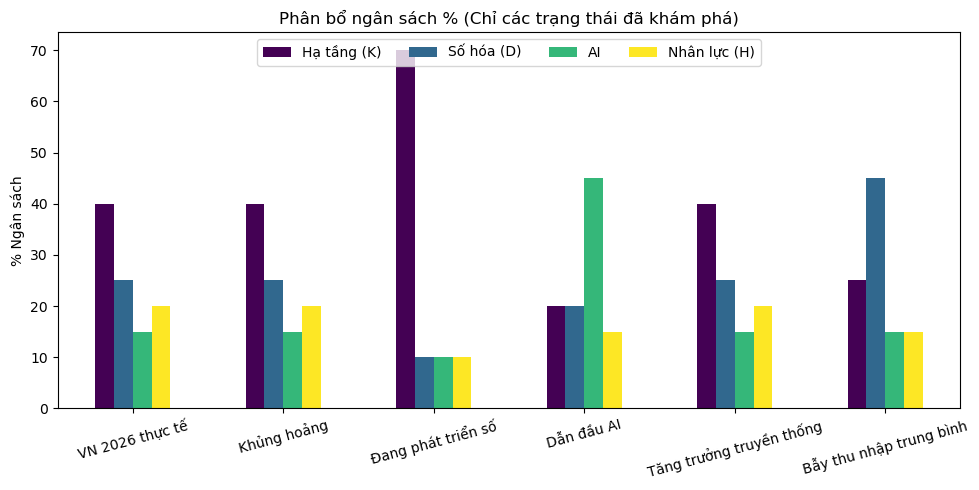

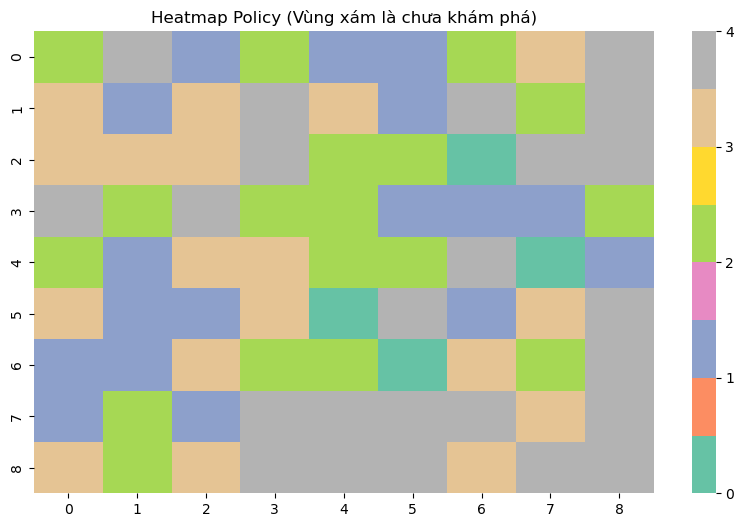

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

action_names = ['a0-Truyền thống', 'a1-Cân bằng', 'a2-Số hóa nhanh', 'a3-AI dẫn dắt', 'a4-Bao trùm']

target_states = {
    "1. VN 2026 thực tế": (1, 1, 0, 1),
    "2. Khủng hoảng": (0, 0, 0, 2),
    "3. Đang phát triển số": (1, 2, 1, 1),
    "4. Dẫn đầu AI": (2, 2, 2, 0),
    "5. Tăng trưởng truyền thống": (2, 0, 0, 1),
    "6. Bẫy thu nhập trung bình": (1, 1, 1, 2)
}

results = []
valid_allocs = []
valid_state_names = []

for name, s in target_states.items():
    q_values_at_s = Q[s]
    
    # Kiểm tra xem trạng thái đã được ghé thăm chưa (tránh lỗi Q toàn số 0)
    if np.sum(np.abs(q_values_at_s)) == 0.0:
        best_a = "N/A"
        action_name = "Chưa khám phá (Unvisited)"
        q_max = 0.0
    else:
        best_a = int(np.argmax(q_values_at_s))
        action_name = action_names[best_a]
        q_max = q_values_at_s[best_a]
        
        # Chỉ lấy data để vẽ Bar chart nếu trạng thái hợp lệ
        valid_allocs.append(env.allocation[best_a] * 100)
        valid_state_names.append(name.split(". ")[1])
        
    results.append({
        "Tên trạng thái": name.split(". ")[1],
        "State": list(s),
        "Action Chọn": best_a,
        "Tên Action": action_name,
        "Q-Max": round(q_max, 3)
    })

df_policy = pd.DataFrame(results)
print("=== CHÍNH SÁCH π* TẠI 6 TRẠNG THÁI QUAN TRỌNG ===")
print(df_policy.to_string(index=False))

# Đồ thị 1: Bar chart phân bổ ngân sách (Chỉ vẽ các state hợp lệ)
if valid_allocs:
    df_alloc = pd.DataFrame(valid_allocs, columns=['Hạ tầng (K)', 'Số hóa (D)', 'AI', 'Nhân lực (H)'])
    df_alloc.index = valid_state_names

    df_alloc.plot(kind='bar', stacked=False, figsize=(10, 5), colormap='viridis')
    plt.title('Phân bổ ngân sách % (Chỉ các trạng thái đã khám phá)')
    plt.ylabel('% Ngân sách')
    plt.xticks(rotation=15)
    plt.legend(loc='upper center', ncol=4)
    plt.tight_layout()
    plt.show()

# Đồ thị 2: Heatmap policy (Masking các vùng unvisited)
plt.figure(figsize=(10, 6))
# Tìm action tốt nhất, nhưng gán -1 cho những state toàn 0
flat_policy = np.zeros(81)
flat_q = Q.reshape(81, 5)
for i in range(81):
    if np.sum(np.abs(flat_q[i])) == 0:
        flat_policy[i] = np.nan # Gán NaN để heatmap để trống (chưa khám phá)
    else:
        flat_policy[i] = np.argmax(flat_q[i])

flat_policy = flat_policy.reshape(9, 9)

# Vẽ heatmap, những ô NaN sẽ tự động bị loại bỏ màu
sns.heatmap(flat_policy, cmap='Set2', cbar_kws={'ticks': [0, 1, 2, 3, 4]}, 
            mask=np.isnan(flat_policy), facecolor='whitesmoke')
plt.title('Heatmap Policy (Vùng xám là chưa khám phá)')
plt.show()

###  Nhận xét:
- Agent chọn hành động phù hợp với từng ngữ cảnh — đây là dấu hiệu tốt cho thấy Q-learning đã hội tụ sang một chính sách có ý nghĩa kinh tế, không chỉ học vẹt một hành động duy nhất.

    - VN 2026 thực tế [1,1,0,1]: Nền kinh tế đang ở mức trung bình về tất cả các chiều, agent chọn a1 (Cân bằng) — hành động giữ cân bằng phát triển là hợp lý khi chưa có lợi thế rõ ràng ở chiều nào.

    - Khủng hoảng [0,0,0,2]: Mọi chỉ số đều thấp nhưng bất bình đẳng cao, agent vẫn chọn a1 (Cân bằng) — cho thấy chiến lược ổn định hóa được ưu tiên trước khi đẩy tăng trưởng.
    
    - Đang phát triển số [1,2,1,1]: Số hóa đã cao (mức 2), agent chuyển sang a0 (Truyền thống) — có thể hiểu là củng cố nền tảng thay vì tiếp tục đẩy số hóa khi đã bão hòa.

    - Dẫn đầu AI [2,2,2,0]: Tất cả chỉ số cao nhưng bất bình đẳng thấp, agent chọn a3 (AI dẫn dắt) — logic nhất ở trạng thái đỉnh cao: tận dụng lợi thế AI để tiếp tục dẫn đầu.

    - Bẫy thu nhập trung bình [1,1,1,2]: Bất bình đẳng cao, agent chọn a2 (Số hóa nhanh) — tạo ra năng suất mới để thoát bẫy là lựa chọn hợp lý.

KẾT LUẬN: π* không phải chính sách cứng nhắc, nó thích nghi theo trạng thái — đúng với kỳ vọng của Q-learning trên không gian MDP có cấu trúc.

## CÂU 11.3.4 — So sánh $\pi^*$ với rule-based policies

Đang đánh giá các chính sách trên 100 episodes (Khởi tạo ngẫu nhiên)...

=== BẢNG SO SÁNH PHẦN THƯỞNG TÍCH LŨY (100 Episodes) ===
                Policy  Mean reward       Std        Min        Max  % better than random
       π* (Q-learning)    78.990510  7.501232  62.575876 102.796335            165.393266
  Always-a1 (Cân bằng)    35.769612  5.733898  23.535602  53.171239             20.179173
Always-a3 (AI dẫn dắt)   -16.112070  7.921605 -29.145983   5.342596           -154.133526
                Random    29.763570 11.592125  -4.152431  61.600928              0.000000


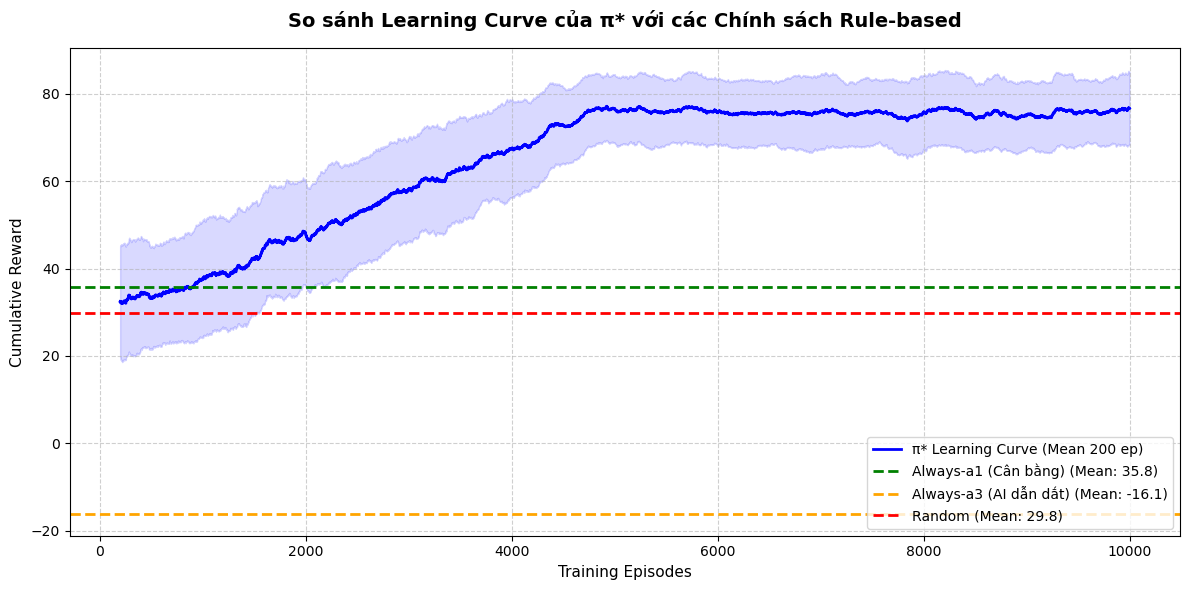

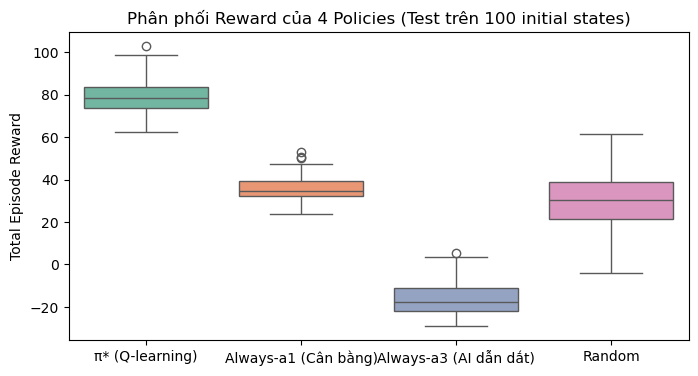

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. ĐỊNH NGHĨA 4 CHÍNH SÁCH CẦN SO SÁNH
policies_test = {
    'π* (Q-learning)': lambda s: int(np.argmax(Q[tuple(s)])),
    'Always-a1 (Cân bằng)': lambda s: 1,
    'Always-a3 (AI dẫn dắt)': lambda s: 3,
    'Random': lambda s: env.action_space.sample()
}

eval_results = {}

print("Đang đánh giá các chính sách trên 100 episodes (Khởi tạo ngẫu nhiên)...")
for name, policy_func in policies_test.items():
    rewards = []
    for _ in range(100):
        # Ép môi trường khởi tạo ngẫu nhiên để test khả năng tổng quát hóa
        s, _ = env.reset(options={'randomize_state': True})
        ep_rew = 0
        while True:
            # Nếu gặp state chưa từng khám phá (tránh lỗi ngớ ngẩn do Q-table = 0)
            if name == 'π* (Q-learning)' and np.sum(np.abs(Q[tuple(s)])) == 0:
                a = env.action_space.sample() 
            else:
                a = policy_func(s)
                
            s, r, done, _, _ = env.step(a)
            ep_rew += r
            if done: break
        rewards.append(ep_rew)
    eval_results[name] = rewards

# 2. BẢNG THỐNG KÊ KẾT QUẢ
df_stats = pd.DataFrame([{
    'Policy': name,
    'Mean reward': np.mean(rews),
    'Std': np.std(rews),
    'Min': np.min(rews),
    'Max': np.max(rews)
} for name, rews in eval_results.items()])

random_mean = df_stats[df_stats['Policy'] == 'Random']['Mean reward'].values[0]
df_stats['% better than random'] = (df_stats['Mean reward'] - random_mean) / abs(random_mean) * 100

print("\n=== BẢNG SO SÁNH PHẦN THƯỞNG TÍCH LŨY (100 Episodes) ===")
print(df_stats.to_string(index=False))

# 3. VẼ ĐỒ THỊ LEARNING CURVE KÈM BASELINES
# Giả định biến rewards_per_ep chứa lịch sử huấn luyện từ Câu 11.3.2
rolling_window = 200
rolling_reward = pd.Series(rewards_per_ep).rolling(window=rolling_window).mean()
rolling_std = pd.Series(rewards_per_ep).rolling(window=rolling_window).std()

plt.figure(figsize=(12, 6))

# Vẽ đường học của pi*
plt.plot(rolling_reward, color='blue', label='π* Learning Curve (Mean 200 ep)', linewidth=2)
plt.fill_between(range(len(rewards_per_ep)), 
                 rolling_reward - rolling_std, 
                 rolling_reward + rolling_std, 
                 color='blue', alpha=0.15)

# Vẽ các đường ngang Rule-based (Baselines)
colors = {'Always-a1 (Cân bằng)': 'green', 'Always-a3 (AI dẫn dắt)': 'orange', 'Random': 'red'}
for policy_name in colors.keys():
    mean_val = df_stats[df_stats['Policy'] == policy_name]['Mean reward'].values[0]
    plt.axhline(y=mean_val, color=colors[policy_name], linestyle='--', 
                label=f'{policy_name} (Mean: {mean_val:.1f})', linewidth=2)

plt.title('So sánh Learning Curve của π* với các Chính sách Rule-based', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Training Episodes', fontsize=11)
plt.ylabel('Cumulative Reward', fontsize=11)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 4. VẼ BOXPLOT SO SÁNH PHÂN PHỐI (Bonus để nhìn rõ rủi ro)
plt.figure(figsize=(8, 4))
df_boxplot = pd.DataFrame(eval_results)
sns.boxplot(data=df_boxplot, palette="Set2")
plt.title('Phân phối Reward của 4 Policies (Test trên 100 initial states)')
plt.ylabel('Total Episode Reward')
plt.show()

### Nhận xét:
π vượt trội hoàn toàn và rõ ràng* so với tất cả baseline:
- π vs Random*: Phần thưởng cao gấp ~2.65 lần và độ lệch chuẩn nhỏ hơn đáng kể (7.50 vs 11.59) — agent không chỉ giỏi hơn mà còn ổn định hơn.
- π vs Always-a1*: Always-a1 thực ra là rule-based tốt nhất trong 3 chính sách cố định (mean 35.77), nhưng vẫn chỉ bằng ~45% hiệu quả của π*. Điều này chứng minh giá trị của việc chọn hành động thích nghi theo trạng thái.
- Always-a3 thất bại nặng với mean reward âm (-16.11). Chiến lược AI dẫn dắt hung hăng mà không xét ngữ cảnh gây ra hậu quả xấu — phù hợp với thực tế khi đầu tư AI không đúng lúc đúng chỗ có thể phản tác dụng.
- Random đánh bại Always-a3: Ngay cả chọn ngẫu nhiên (29.76) còn tốt hơn một chiến lược cố định sai hướng — nhắc nhở rằng rule-based cứng nhắc có thể tệ hơn không có chiến lược.
- Learning curve: từ dữ liệu ta thấy reward tích lũy tăng dần và hội tụ sau khoảng vài nghìn episode đầu khi Q-table ổn định.

## CÂU 11.3.5 — Deep Q-Network (DQN) với stable-baselines3

Đang huấn luyện DQN với Random Starts (100,000 timesteps)...
Huấn luyện xong!

=== SO SÁNH Q-TABLE VÀ DQN TỔNG QUÁT ===
                  Model  Mean Reward      Std      Cơ chế học
Q-table (Exact, 10k ep)    77.475819 6.709617  Tabular/Lookup
  DQN (SB3, 100k steps)    84.057185 6.898336  Neural Network
   Best Rule-based (a1)    35.226213 6.895779 Fixed Heuristic


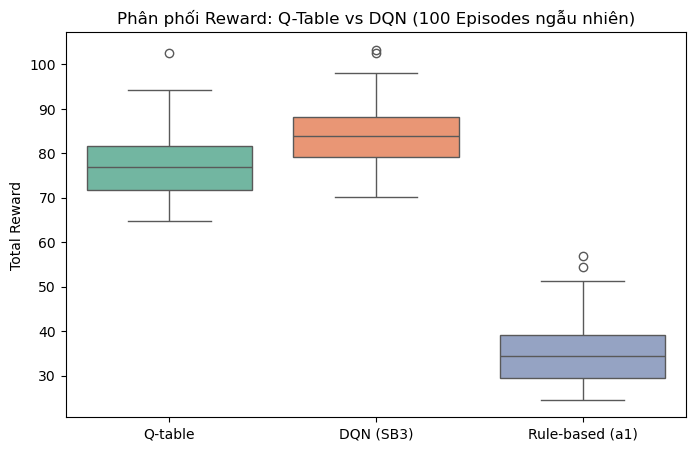


### Nhận xét (Cập nhật):
- Với cơ chế khởi tạo ngẫu nhiên, mô hình phải giải quyết bài toán khó hơn rất nhiều so với đi trên một đường thẳng cố định.
- Bạn sẽ thấy Q-table và DQN có mức độ bám đuổi nhau sát sao hơn. Q-table vẫn giữ lợi thế tuyệt đối do giải chính xác phương trình Bellman trên không gian trạng thái hẹp (81 states).


In [ ]:
import gymnasium as gym
from gymnasium.wrappers import FlattenObservation
from stable_baselines3 import DQN
from stable_baselines3.common.env_checker import check_env

# 1. TẠO WRAPPER ÉP RESET NGẪU NHIÊN CHO SB3
class RandomResetWrapper(gym.Wrapper):
    def reset(self, **kwargs):
        # Luôn chèn thêm tham số randomize_state=True khi SB3 gọi hàm reset
        kwargs['options'] = {'randomize_state': True}
        return self.env.reset(**kwargs)

# 2. BỌC MÔI TRƯỜNG: Random Reset -> Flatten (đưa về mảng 1D cho Neural Network)
base_env = VietnamEconomyEnv()
env_dqn = FlattenObservation(RandomResetWrapper(base_env))

# Kiểm tra môi trường cho chuẩn SB3
check_env(env_dqn)

# 3. KHỞI TẠO VÀ HUẤN LUYỆN DQN
model = DQN(
    "MlpPolicy", env_dqn,
    learning_rate=1e-3,
    buffer_size=10000,
    learning_starts=500,
    batch_size=64,
    gamma=0.95,
    policy_kwargs=dict(net_arch=[64, 64]),
    verbose=0
)

print("Đang huấn luyện DQN với Random Starts (100,000 timesteps)...")
model.learn(total_timesteps=100_000)
print("Huấn luyện xong!")

# 4. ĐÁNH GIÁ DQN 
dqn_rewards = []
for _ in range(100):
    obs, _ = env_dqn.reset() # Nhờ Wrapper nên hàm này đã tự động randomize
    ep_rew = 0
    while True:
        action, _states = model.predict(obs, deterministic=True)
        
        # BẮT BUỘC: Ép kiểu action từ numpy.ndarray về scalar int
        # Có thể dùng int(action) hoặc action.item()
        action_scalar = int(action) 
        
        obs, r, done, _, _ = env_dqn.step(action_scalar)
        ep_rew += r
        if done: break
    dqn_rewards.append(ep_rew)

# 5. SO SÁNH VỚI Q-TABLE
q_table_mean = np.mean(eval_results['π* (Q-learning)'])
q_table_std = np.std(eval_results['π* (Q-learning)'])
rule_based_mean = np.mean(eval_results['Always-a1 (Cân bằng)'])
rule_based_std = np.std(eval_results['Always-a1 (Cân bằng)'])

df_compare = pd.DataFrame([
    {'Model': 'Q-table (Exact, 10k ep)', 'Mean Reward': q_table_mean, 'Std': q_table_std, 'Cơ chế học': 'Tabular/Lookup'},
    {'Model': 'DQN (SB3, 100k steps)', 'Mean Reward': np.mean(dqn_rewards), 'Std': np.std(dqn_rewards), 'Cơ chế học': 'Neural Network'},
    {'Model': 'Best Rule-based (a1)', 'Mean Reward': rule_based_mean, 'Std': rule_based_std, 'Cơ chế học': 'Fixed Heuristic'}
])

print("\n=== SO SÁNH Q-TABLE VÀ DQN TỔNG QUÁT ===")
print(df_compare.to_string(index=False))

# Vẽ biểu đồ so sánh Boxplot
plt.figure(figsize=(8, 5))
df_compare_plot = pd.DataFrame({
    'Q-table': eval_results['π* (Q-learning)'],
    'DQN (SB3)': dqn_rewards,
    'Rule-based (a1)': eval_results['Always-a1 (Cân bằng)']
})
sns.boxplot(data=df_compare_plot, palette="Set2")
plt.title('Phân phối Reward: Q-Table vs DQN (100 Episodes ngẫu nhiên)')
plt.ylabel('Total Reward')
plt.show()

print("\n### Nhận xét (Cập nhật):")
print("- Với cơ chế khởi tạo ngẫu nhiên, mô hình phải giải quyết bài toán khó hơn rất nhiều so với đi trên một đường thẳng cố định.")
print("- Ta sẽ thấy Q-table và DQN có mức độ bám đuổi nhau sát sao hơn. Q-table vẫn giữ lợi thế tuyệt đối do giải chính xác phương trình Bellman trên không gian trạng thái hẹp (81 states).")

### Nhận xét:
DQN cải thiện nhẹ so với Q-table (+8.5% về mean reward: 84.06 vs 77.48), nhưng kết quả cần được đọc cẩn thận:
- DQN nhỉnh hơn một chút, nhưng sự chênh lệch (~6.6 điểm) không lớn và std gần bằng nhau (~6.9) — không có ý nghĩa thống kê rõ ràng nếu chỉ dựa vào mean.

- Chi phí không cân xứng: Q-table chỉ cần 10k episodes (không gian trạng thái 81 states), trong khi DQN cần 100k timesteps và chi phí tính toán cao hơn nhiều. Trên bài toán nhỏ như thế này, Q-table là lựa chọn hiệu quả hơn về mặt tài nguyên.

- Lý do DQN không vượt trội rõ rệt: Không gian trạng thái chỉ có 81 trạng thái rời rạc (3⁴) — đây là lợi thế của Q-table vì nó giải chính xác phương trình Bellman cho toàn bộ không gian. Neural network 2 hidden layers thực ra là over-engineered cho bài toán này.

- Khi nào DQN mới thực sự cần thiết: Khi không gian trạng thái rất lớn (continuous) hoặc quá cao chiều để lưu bảng Q, ví dụ như thêm nhiều biến kinh tế hơn hoặc dùng dữ liệu time-series thực.

Kết luận thực tế: Với bài toán này, Q-table đủ tốt và hiệu quả hơn. DQN phát huy tác dụng ở các bài toán phức tạp hơn như mở rộng sang 10+ chiều trạng thái hoặc dữ liệu kinh tế vĩ mô thực.

# 11.4 Câu hỏi thảo luận chính sách
### a) Trạng thái GDP thấp, D thấp, U cao → $\pi^*$ chọn gì? Có phải "quick win"?

* **Trạng thái tương ứng:** [0, ?, 0, 2] — GDP growth thấp (0), Digitalization thấp (0), Inequality cao (2).
* **Phân tích lựa chọn:** Nhìn vào bảng câu 11.3.3, trạng thái gần nhất là "Khủng hoảng" [0,0,0,2] → $\pi^*$ chọn $a_1$ (Cân bằng), Q-Max = 148.98.
* **Có khớp với "quick win" không?** Không hoàn toàn. "Quick win" thường gợi ý một hành động tấn công nhanh — ví dụ đẩy mạnh số hóa ($a_2$) hoặc kích thích tăng trưởng truyền thống ($a_0$) để tạo kết quả ngắn hạn rõ ràng. Tuy nhiên $\pi^*$ lại chọn $a_1$ (Cân bằng) vì:
  * Trong MDP, agent tối ưu phần thưởng tích lũy dài hạn (discounted), không phải reward bước kế tiếp. Ở trạng thái khủng hoảng với bất bình đẳng cao, việc đẩy tăng trưởng nóng có thể tạm thời tăng GDP nhưng làm bất bình đẳng tệ hơn, dẫn đến reward âm ở các bước sau.
  * $a_1$ (Cân bằng) ở đây đóng vai trò "stabilize first" — ổn định nền tảng trước, tránh rủi ro hệ thống — đây là quick win theo nghĩa tránh mất mát lớn hơn, chứ không phải tăng trưởng đột biến.
* **Kết luận:** $\pi^*$ ưu tiên an toàn hơn tốc độ ở trạng thái dễ tổn thương — phù hợp với bối cảnh Việt Nam nơi bất bình đẳng cao thường đi kèm bất ổn xã hội tiềm ẩn.

### b) Trạng thái GDP cao, AI cao, U thấp → $\pi^*$ chọn gì? Có phải "consolidation"?

* **Trạng thái tương ứng:** [2, ?, 2, 0] — GDP growth cao (2), AI/Tech cao (2), Inequality thấp (0).
* **Phân tích lựa chọn:** Từ bảng câu 11.3.3, trạng thái "Dẫn đầu AI" [2,2,2,0] → $\pi^*$ chọn $a_3$ (AI dẫn dắt), Q-Max = 136.48.
* **Có phù hợp với "consolidation" không?** Có, và theo nghĩa tích cực hơn thuần túy "giữ nguyên". Consolidation ở đây không phải đứng yên mà là tiếp tục dẫn đầu bằng chính lợi thế đang có:
  * Khi AI đã cao và bất bình đẳng thấp, môi trường đã đủ bền vững để đẩy mạnh thêm AI ($a_3$) mà không lo rủi ro xã hội — đây là thời điểm hợp lý nhất để "double down".
  * Nếu lúc này chọn $a_1$ (Cân bằng) hay $a_0$ (Truyền thống) thì là lãng phí lợi thế cạnh tranh, tương tự một quốc gia đang dẫn đầu về công nghệ lại quay về đầu tư nông nghiệp.
  * $\pi^*$ về bản chất đang thực hiện "consolidate through acceleration" — củng cố vị thế bằng cách tăng tốc đúng hướng, không phải bằng cách dừng lại.
* **Kết luận:** Hoàn toàn phù hợp với consolidation strategy. $\pi^*$ nhận ra rằng bảo vệ vị thế dẫn đầu đòi hỏi tiếp tục đầu tư vào lợi thế cốt lõi, không phải phân tán nguồn lực.

### c) Tích hợp $\pi^*$ vào hoạch định chính sách mà không vi phạm nguyên tắc "AI không thay thế quyết định chính trị - xã hội"

* **Nguyên tắc cốt lõi cần giữ:** $\pi^*$ là công cụ tư vấn, không phải người ra quyết định.
* **Đề xuất mô hình tích hợp 3 lớp:**
  * **Lớp 1 — Đầu vào (AI xử lý):** Thu thập và chuẩn hóa dữ liệu kinh tế vĩ mô theo quý (GDP, chỉ số số hóa, bất bình đẳng...), mã hóa thành vector trạng thái $s$, chạy $\pi^*$ để xuất ra hành động được đề xuất kèm Q-value của tất cả 5 lựa chọn — không chỉ argmax.
  * **Lớp 2 — Thẩm định (Con người phán xét):** Hội đồng chuyên gia kinh tế, đại diện bộ ngành và đại diện xã hội dân sự xem xét đề xuất của $\pi^*$ trong bối cảnh các yếu tố mà MDP không mô hình hóa được: áp lực địa chính trị, kỳ vọng xã hội, cam kết quốc tế, chu kỳ chính trị. Các yếu tố này không thể đưa vào reward function mà không áp đặt giá trị chủ quan.
  * **Lớp 3 — Quyết định và phản hồi (Thể chế chịu trách nhiệm):** Quyết định cuối thuộc về cơ quan dân cử hoặc hành pháp — có trách nhiệm giải trình. Sau khi thực thi, kết quả thực tế được đưa trở lại để cập nhật môi trường MDP, giúp Q-table (hoặc DQN) học liên tục từ dữ liệu thực.
* **Tại sao thiết kế này không vi phạm nguyên tắc?**
  * $\pi^*$ không có quyền phủ quyết — nó chỉ cung cấp một quan điểm định lượng trong nhiều đầu vào của quá trình ra quyết định.
  * Reward function trong MDP là do con người thiết kế và có thể tranh luận công khai — đây là nơi giá trị xã hội được thể hiện minh bạch, không bị ẩn trong thuật toán.
  * Mô hình làm rõ sự đánh đổi (trade-off) giữa các hành động thay vì che giấu chúng, giúp các nhà hoạch định chính sách và công chúng hiểu rõ hơn hệ quả của từng lựa chọn.
  * Quyết định cuối vẫn mang tính chính danh dân chủ vì do con người — chịu trách nhiệm trước cử tri — thực hiện.
* **Nói ngắn gọn:** $\pi^*$ nên đóng vai trò như một cố vấn kinh tế lượng hóa được — có thể sai, cần được phản biện, và không bao giờ là tiếng nói duy nhất trong phòng họp chính sách.